In [1]:
import shutil
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pyblock.blocking

from jaqmc.utils.config import ConfigManager

In [2]:
digest = dict(np.load("/rds/user/jc2405/hpc-work/JaQMC/jaqmc/runs/h_chain_3.78_2_h_3_supcell_momentum_eval/evaluation_digest.npz"))

print("Digest contents:")
for key, value in sorted(digest.items()):
    if value.ndim == 0:
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: shape={value.shape}")

print(digest["n_k_total"])

Digest contents:
  energy:kinetic: 2.635439-0.000040j
  energy:kinetic_var: 5.453382-0.001044j
  energy:potential: -5.721750
  energy:potential_var: 5.451805
  n_k_total: shape=(6,)
  total_energy: -3.086311-0.000040j
  total_energy_real: -3.086311
  total_energy_real_var: 0.000874
[0.24502338 0.44350228 1.5637072  1.7407568  1.5632888  0.44372085]


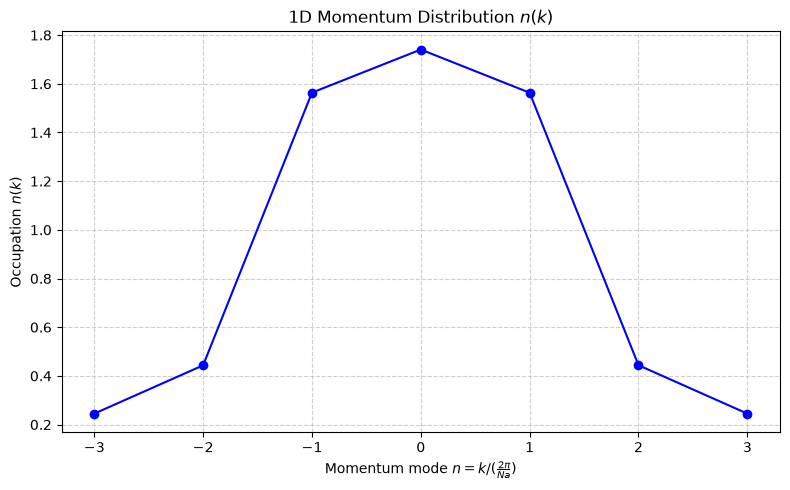

In [7]:
# In estimator k_vals defined by:
# n_vals = jnp.arange(-self.N // 2, self.N // 2 )
# k_vals = 2.0 * jnp.pi * n_vals / (self.N * self.a)


import matplotlib.pyplot as plt

# Extract the array and convert it to a standard Python list
nk_original = digest["n_k_total"].tolist()

# Now the + operator will correctly concatenate (append) the first value to the end
nk_vals = nk_original + [nk_original[0]]

# The corresponding n modes for N=6, plus the appended boundary
n_vals = [-3, -2, -1, 0, 1, 2, 3]

plt.figure(figsize=(8, 5))

# Plotting straight data in points
plt.plot(n_vals, nk_vals, marker='o', linestyle='-', color='b', linewidth=1.5, markersize=6)

plt.title("1D Momentum Distribution $n(k)$")
plt.xlabel(r"Momentum mode $n = k / (\frac{2\pi}{Na})$")
plt.ylabel(r"Occupation $n(k)$")

# Lock the x-ticks exactly to the integer modes
plt.xticks(n_vals)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
